In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/ML-Data")


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |


_

Przed przystąpieniem do dalszych kroków, poddajmy dane prostej analizie.

In [3]:
titanic_df = pd.read_csv(base_path/'titanic.csv')

Funkcje pomagające analizie danych

In [4]:
def get_percentage_missing_columns(df):
  """
    Zwraca procent brakujących wartości (NaN) w kolumnach DataFrame.

    df : Tabela danych, dla której liczone są braki.
  """
  missing_cols = df.isna().sum(axis=0)
  missing_cols_perc = np.round(missing_cols / df.shape[0] * 100, 2)
  return missing_cols_perc[missing_cols_perc > 0]

In [5]:
def plot_numeric_histogram(df, column_name):
    """
    Tworzy histogram danych na podstawie podanych zmiennych:
        df (DataFrane): Podany DataFrame z danymi
        column_name (str): nazwa kolumny na podstawie której powstanie plot
    """

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
def plot_categorical_column(df, column_name):
    """
    Twoży wykres kolumnowy na podstawie podanych zmiennych
        df (DataFrane): Podany DataFrame z danymi
        column_name (str): nazwa kolumny na podstawie której powstanie plot
    """

    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

In [7]:
def make_box_plot(df, column_name):
    """
    Tworzy wykres pudełkowy na podstawie podanych zmiennych:
        df (DataFrane): Podany DataFrame z danymi
        column_name (str): nazwa kolumny na podstawie której powstanie plot
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=column_name, data=df, color='steelblue')
    plt.title(f'Box Plot of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Value')
    plt.show()

Analiza:

In [8]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         793 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Możemy zobaczyć, że wszystkie dane posiadają poprawny rodzaj danych.

In [9]:
get_percentage_missing_columns(titanic_df)

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Czyszczenie danych:

Na podstawie, przedstawionego problemu oraz informacji o rodzajach kolumn oraz ilości błędów, skłaniam się ku usunięciu wg. mnie nie potrzebnych kolumn:
PassangerId, Name, Ticket, Cabin (ze względu na ilość brakujących danych), Embarked. Dodatkowo scaliłbym dane z SibSp i Parch na wspólną kolumnę wielkości rodziny.

In [10]:
new_column = titanic_df['SibSp'] + titanic_df['Parch']
titanic_df.insert(loc=4, column='FamilySize', value=new_column)

In [11]:
titanic_df_striped = titanic_df.drop(labels=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked', 'SibSp', 'Parch'], axis=1, errors='ignore')

Następnie trzeba wypełnić dane których nie posiadamy, oraz podmienić dane kategorialne na liczby.

Podmienimy płci za pomocą kodowania binarnego.

In [12]:
titanic_df_striped['Sex'] = titanic_df_striped.Sex.map({'male': 1, 'female': 0})

Ok, teraz sprawdźmy rozkłady kolumn z brakującymi elementami. To pozwoli nam na dobór odpowiedniej metody wstawiania brakujących danych.

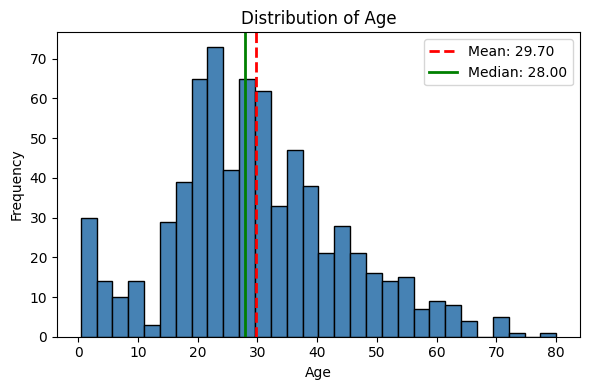

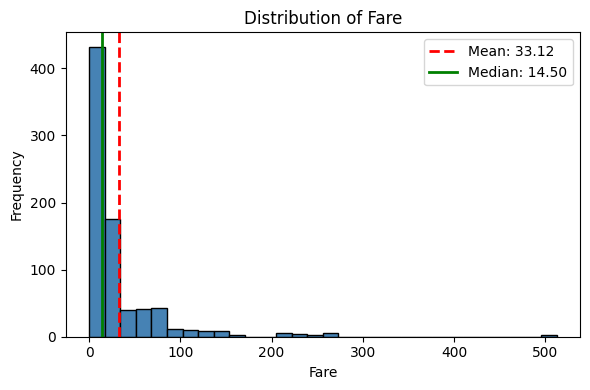

In [13]:
plot_numeric_histogram(titanic_df_striped, 'Age')
plot_numeric_histogram(titanic_df_striped, 'Fare')

Na podstawie tych wykresów możemy stwierdzić, że oba rozkłady nie są normalne (choć wiek go przypomina). Dla tego skorzystam z mediany, ale aby dane były bardziej prawidłowe podzielę ich na klasy ze względu na to, że ceny w 1 są większe niż w 3.

In [14]:
mediana_wiek_klasa = titanic_df_striped.groupby('Pclass')['Age'].transform('median')
titanic_df_striped['Age'] = titanic_df_striped['Age'].fillna(mediana_wiek_klasa)

In [15]:
mediana_cena_klasa = titanic_df_striped.groupby('Pclass')['Fare'].transform('median')
titanic_df_striped['Fare'] = titanic_df_striped['Fare'].fillna(mediana_cena_klasa)

Zadanie wymagało dwóch dodatkowych kolumn, więc musiałem dodać następną. Postawiłem na tytuły grzecznościowe.

In [16]:
new_titles = titanic_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

new_titles = new_titles.replace(['Mlle', 'Ms'], 'Miss')
new_titles = new_titles.replace('Mme', 'Mrs')

rzadkie_tytuly = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr',
                  'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
new_titles = new_titles.replace(rzadkie_tytuly, 'Status')

titanic_df_striped.insert(loc=2, column='Title', value=new_titles)

Teraz trzeba to zakodować. Kodowanie binarne, ani kodowanie numeryczne tu nie zadziała (brak jasnej kolejności) dla tego zostaje mi tu One-hot encoding.

In [17]:
titanic_df_striped = pd.get_dummies(titanic_df_striped, columns=['Title'], dtype=int)

Skoro nasze dane są już przygotowane możemy przejść do bardziej dogłębnej analizy na podstawie wykresów:

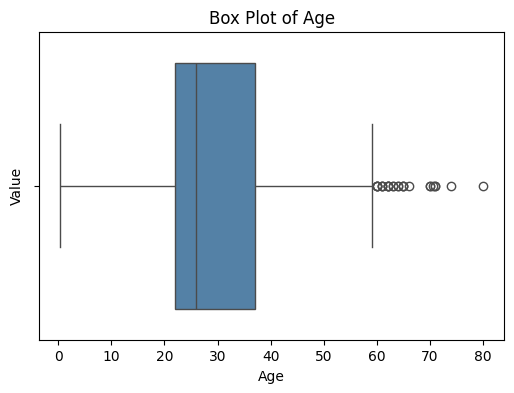

In [18]:
make_box_plot(titanic_df_striped, 'Age')

Na wykresie pudełkowym widzimny parę wartości odstających, lecz ze względu na ich znaczenie (wiek) nie powinniśmy ich traktować jako błędów, lecz informacje o tym, że na statku było stosunkowo niewiele osób o wieku 60+.

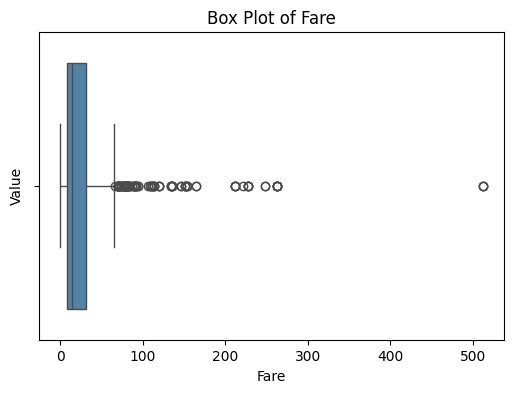

In [19]:
make_box_plot(titanic_df_striped, 'Fare')

Tu wykres wygląda nieco gorzej, dzieje się tak ze względu na rozkład prawostronny, który mówi nam o tym, że większość biletów była tańsza (w granicach koło 15\$). Taki rozkład mógłby być nieco niewygodny dla algorytmu więc możliwe, że trzeba by było zastosować dodatkowe algorytmy transofrmacji. Ciekawym też jest wartość koło 500\$. Wygląda to na duży błąd ale realnie ceny w tamtych czasach mogły być na prawdę wysokie dla arystokracji.


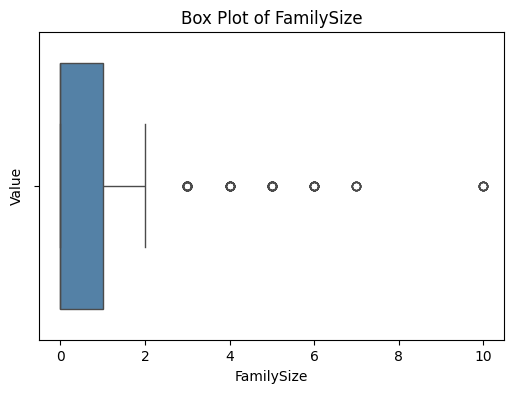

In [20]:
make_box_plot(titanic_df_striped, 'FamilySize')

Na tym możemy zobaczyć, że większość ludzi podróżowała samemu bądź w parę. Te outliery również nie będą dla nas błędami.

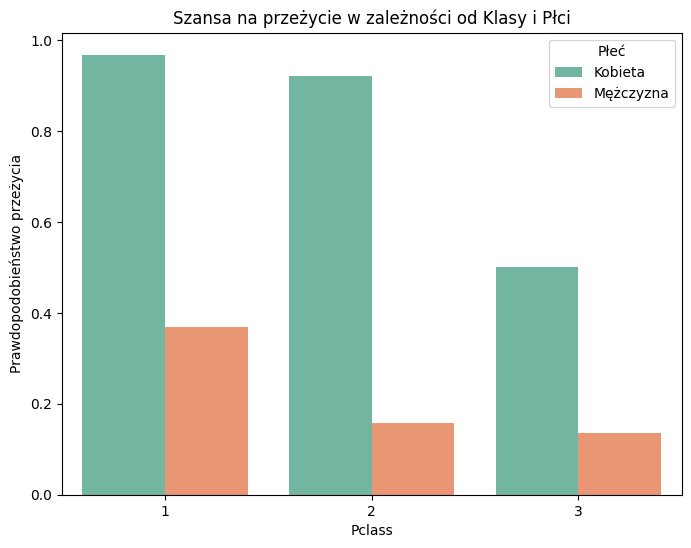

In [21]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=titanic_df_striped, x='Pclass', y='Survived', hue='Sex', palette='Set2', errorbar=None)

handles, labels = ax.get_legend_handles_labels()

label_map = {'0': 'Kobieta', '1': 'Mężczyzna'}
new_labels = [label_map.get(label, label) for label in labels]

ax.legend(handles=handles, labels=new_labels, title='Płeć')
plt.title('Szansa na przeżycie w zależności od Klasy i Płci')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

Ten wykres dogłębnie pokazuje nam kto był prioretyzowany w trakcie ratunku (głównie kobiety). Możemy też zauważyć, że osoby z trzeciej klasy miały o koło 50% mniejsze szanse na przeżycie.

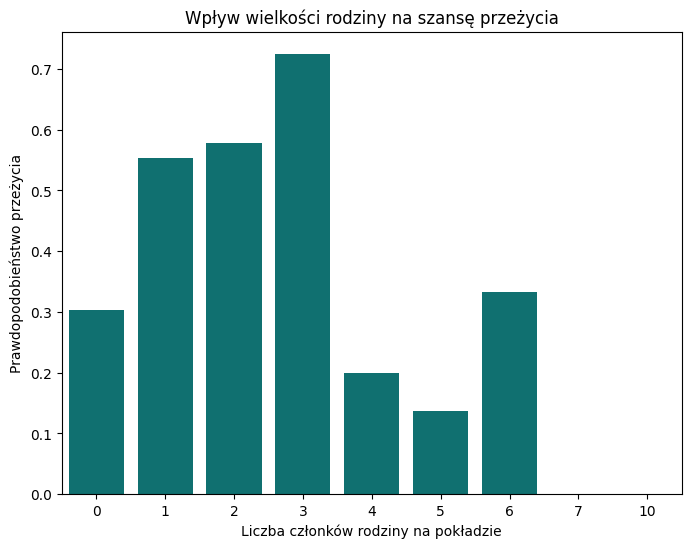

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(data=titanic_df_striped, x='FamilySize', y='Survived', color='teal', errorbar=None)
plt.title('Wpływ wielkości rodziny na szansę przeżycia')
plt.xlabel('Liczba członków rodziny na pokładzie')
plt.ylabel('Prawdopodobieństwo przeżycia')
plt.show()

Tutaj widzimy, że największe szanse na przeżycie miały mniejsze rodziny. Może to wynikaź z tego, że większe rodziny mogły się szukać na statku. Zgaduję też, że osoby które były tam same mają niską przeżywalność ze względu, że raczej byli to głównie mężczyźni.

In [23]:
filtered_df = titanic_df_striped[titanic_df_striped['FamilySize'] == 0]
wynik = filtered_df.groupby('Sex').size()
wynik

,0
Sex,
0,126
1,411


Tak jak myślałem.


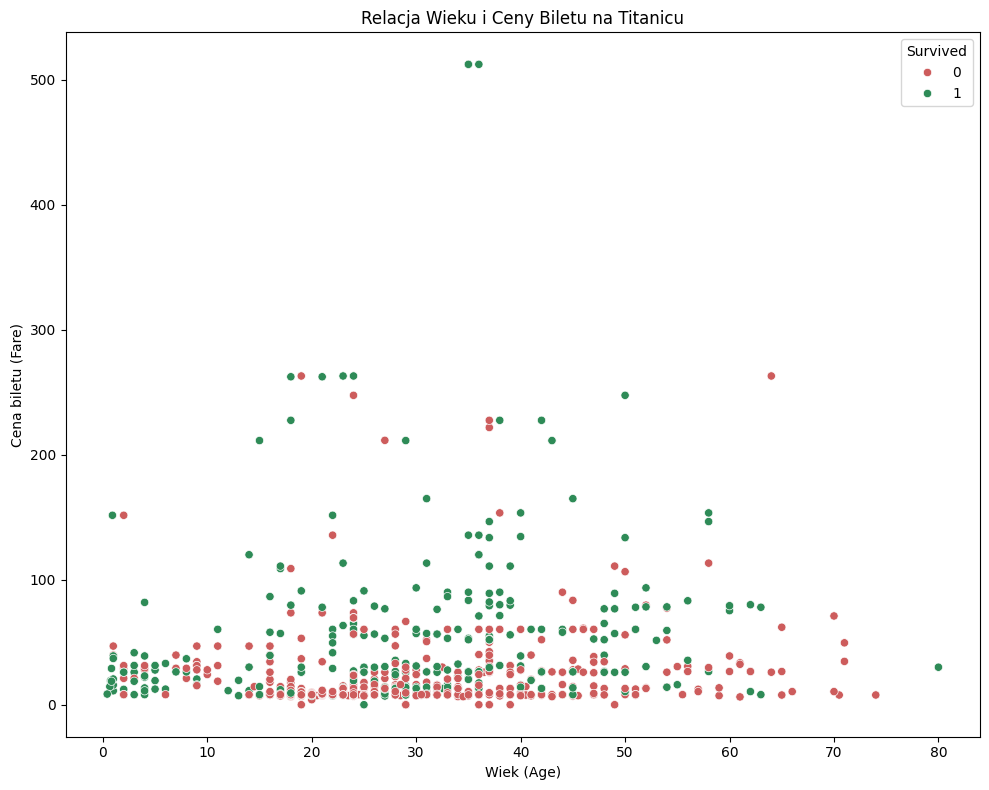

In [24]:
plt.figure(figsize=(10, 8))

# Dodajemy hue='Survived', co automatycznie pokoloruje punkty i doda legendę
sns.scatterplot(data=titanic_df_striped, x='Age', y='Fare',
                hue='Survived', palette={0: 'indianred', 1: 'seagreen'})

plt.title("Relacja Wieku i Ceny Biletu na Titanicu")
plt.xlabel("Wiek (Age)")
plt.ylabel("Cena biletu (Fare)")
plt.tight_layout()
plt.show()

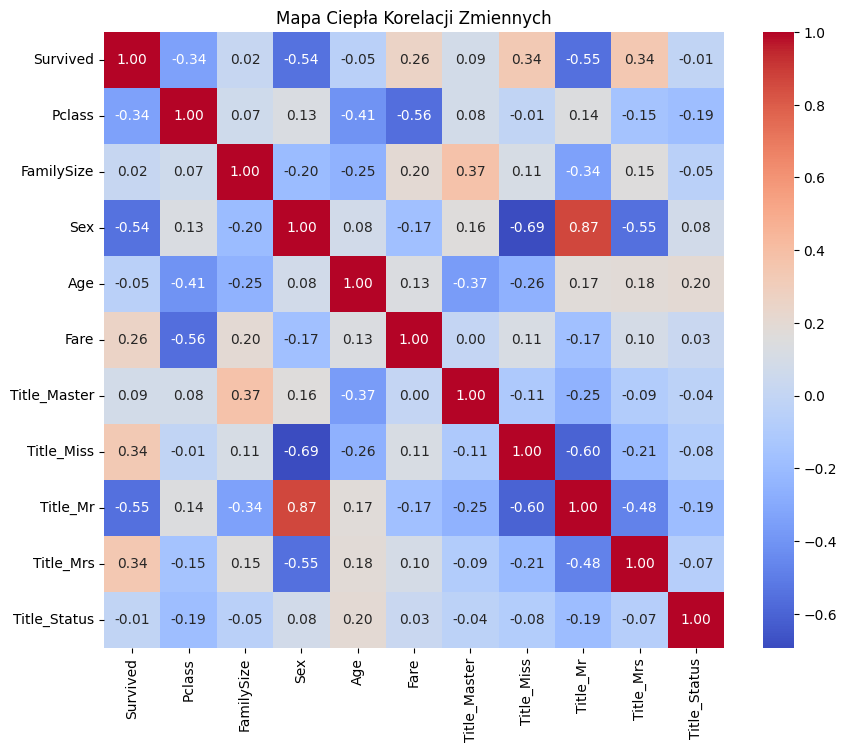

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(titanic_df_striped.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa Ciepła Korelacji Zmiennych')
plt.show()